In [154]:
from datasets import load_from_disk
import numpy as np
from transformers import (
	AutoModelForMaskedLM,
	AutoModelForSequenceClassification,
	AutoTokenizer,
	DataCollatorForLanguageModeling,
	Trainer,
	TrainingArguments,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [155]:
seed = 42

large_dataset_path = "data/my_saved_dataset_large"
base_model_path = "data/my_saved_model"
output_model_path = "data/my_pretrained_model"
text_column = "text"

In [156]:
print("Loading large dataset...")
large_dataset = load_from_disk(large_dataset_path)
num_samples = 1000
large_dataset = large_dataset.shuffle(seed=seed).select(range(num_samples))


Loading large dataset...


In [157]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_path)

Loading tokenizer...


In [158]:
print("Loading base model...")
model = AutoModelForMaskedLM.from_pretrained(base_model_path).to("xpu")

Loading base model...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3063.54it/s]
[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] BertForMaskedLM LOAD REPORT from: data/my_saved_model
Key                                        | Status     | 
-------------------------------------------+------------+-
classifier.bias                            | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | UNEXPECTED | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.pred

In [159]:
def tokenize_batch_large_dataset(batch):
	return tokenizer(
		batch[text_column]	
		, truncation=True,
		max_length=64,
	)

print("Tokenizing text column...")
tokenized_dataset = large_dataset.map(tokenize_batch_large_dataset, batched=True, remove_columns=large_dataset.column_names)


Tokenizing text column...


In [160]:
data_collator = DataCollatorForLanguageModeling(
	tokenizer=tokenizer,
	mlm=True,
	mlm_probability=0.15,
)

In [161]:
training_args = TrainingArguments(
	output_dir=output_model_path,
	per_device_train_batch_size=4,
	learning_rate=5e-5,
	num_train_epochs=1,
	logging_steps=50,
	save_steps=500,
	weight_decay=0.01,
	remove_unused_columns=False,
	report_to="none",
)

trainer = Trainer(
	model=model,
	args=training_args,
	train_dataset=tokenized_dataset,
	data_collator=data_collator
)

In [162]:
print("Starting training on unlabeled text...")
trainer.train()

print("Saving trained model and tokenizer...")
model.save_pretrained(output_model_path)
unlabaled_trained_model = model.to("xpu")
print(f"Finished unsupervised training. Saved to {output_model_path}")


Starting training on unlabeled text...


Step,Training Loss
50,8.142466
100,7.045345
150,6.417408
200,6.456159
250,6.287115


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


Saving trained model and tokenizer...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.21it/s]

Finished unsupervised training. Saved to data/my_pretrained_model


In [163]:
small_dataset_path = "data/my_saved_dataset_small"
print("Loading small dataset...")
small_dataset = load_from_disk(small_dataset_path)
combo_column = "combo"
small_dataset = small_dataset.map(
	lambda example: {
		combo_column: f"{example['politics'][0]}{example['sentiment'][0]}".upper()
	}
)
small_dataset = small_dataset.class_encode_column(combo_column)

Loading small dataset...


In [164]:
split_dataset = small_dataset.train_test_split(
	test_size=0.5,
	seed=seed,
	stratify_by_column=combo_column
)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]
print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

Train size: 1692 | Test size: 1692


In [165]:
def tokenize_with_labels(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,
        padding="max_length",
    )
    tokens["labels"] = batch[combo_column]
    return tokens

train_tokens = train_dataset.map(
	tokenize_with_labels,
	batched=True,
	remove_columns=train_dataset.column_names
)
test_tokens = test_dataset.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=test_dataset.column_names
)

In [166]:
label2id = {
    "LP": 0,
    "LN": 1,
    "RP": 2,
    "RN": 3
}

clf_model = AutoModelForSequenceClassification.from_pretrained(
    output_model_path,
    num_labels=2,
    label2id=label2id,
    id2label={value: key for key, value in label2id.items()},
    ignore_mismatched_sizes=True,
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8844.67it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: data/my_pretrained_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if 

In [167]:
cls_args = TrainingArguments(
	output_dir="tmp_eval",
	report_to="none",
	per_device_train_batch_size=8,
	per_device_eval_batch_size=8,
	learning_rate=5e-5,
	num_train_epochs=1,
)

# source for base code is https://medium.com/@rakeshrajpurohit/customized-evaluation-metrics-with-hugging-face-trainer-3ff00d936f99
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

pred_trainer = Trainer(
	model=clf_model,
	args=cls_args,
	train_dataset=train_tokens,
	eval_dataset=test_tokens,
    compute_metrics=compute_metrics
)
print("Starting training with metrics...")
pred_trainer.train()

Starting training with metrics...


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]


TrainOutput(global_step=212, training_loss=0.4491805670396337, metrics={'train_runtime': 43.3868, 'train_samples_per_second': 38.998, 'train_steps_per_second': 4.886, 'total_flos': 55648987490304.0, 'train_loss': 0.4491805670396337, 'epoch': 1.0})

Evaluation results:


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.221610,212,0.922577,0.923568,0.922577,0.922545


eval_loss: 0.2216
eval_accuracy: 0.9226
eval_precision: 0.9236
eval_recall: 0.9226
eval_f1: 0.9225


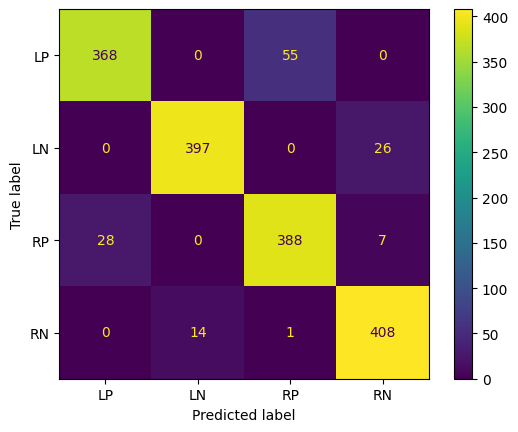

In [168]:
print("Evaluation results:")
results = pred_trainer.evaluate()
for metric_name, metric_value in results.items():
    print(f"{metric_name}: {metric_value:.4f}")


pred_output = pred_trainer.predict(test_tokens)
predictions = np.argmax(pred_output.predictions, axis=-1)
true_labels = np.array(test_tokens["labels"])
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LP', 'LN', 'RP', 'RN'])
disp.plot()
plt.show()